In [12]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM
from tensorflow.keras.layers import Dense, Dropout

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')



In [13]:
train_df = pd.read_csv("/content/drive/MyDrive/AI_part3_Final/train_movie_review.csv")
val_df = pd.read_csv("/content/drive/MyDrive/AI_part3_Final/val_movie_review.csv")
test_df = pd.read_csv("/content/drive/MyDrive/AI_part3_Final/test_movie_review.csv")

In [14]:
print("Training Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Testing Shape:", test_df.shape)

Training Shape: (35000, 3)
Validation Shape: (5000, 3)
Testing Shape: (10000, 3)


In [15]:
train_df.head(10)

,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0
5,39689,Arthur is middle aged rich 'kid' who drinks li...,1
6,41256,"Best fan boy movie I've ever watched save ""Fre...",1
7,27102,"""The King is Alive"" is a flawed and contrived ...",0
8,41833,Note that I did not say that it is better...ju...,1
9,31135,I'm a huge Zack Allan fan and was disappointed...,0


**Data Cleaning**

In [16]:
print(train_df.isnull().sum())
print(val_df.isnull().sum())
print(test_df.isnull().sum())

Unnamed: 0    0
review        0
sentiment     0
dtype: int64
Unnamed: 0    0
review        0
sentiment     0
dtype: int64
Unnamed: 0    0
review        0
sentiment     0
dtype: int64


In [17]:
train_df = train_df[train_df['sentiment'] != 'unsup']
val_df = val_df[val_df['sentiment'] != 'unsup']
test_df = test_df[test_df['sentiment'] != 'unsup']

In [18]:
train_df['sentiment'].value_counts()

,count
sentiment,
0,17584
1,17416


In [19]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r'\d+', '', text)

    words = text.split()

    important_words = {"not", "no", "very", "but", "never"}

    words = [
        word for word in words
        if word not in stop_words or word in important_words
    ]

    return " ".join(words)

train_df['clean_review'] = train_df['review'].apply(clean_text)

val_df['clean_review'] = val_df['review'].apply(clean_text)

test_df['clean_review'] = test_df['review'].apply(clean_text)

print("Enhanced preprocessing completed!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Enhanced preprocessing completed!


In [20]:
X_train = train_df['clean_review']
y_train = train_df['sentiment']

X_val = val_df['clean_review']
y_val = val_df['sentiment']

X_test = test_df['clean_review']
y_test = test_df['sentiment']

In [21]:
max_words = 50000

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [22]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_val_seq = tokenizer.texts_to_sequences(X_val)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [23]:
max_length = 300

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

**Data Visualization**

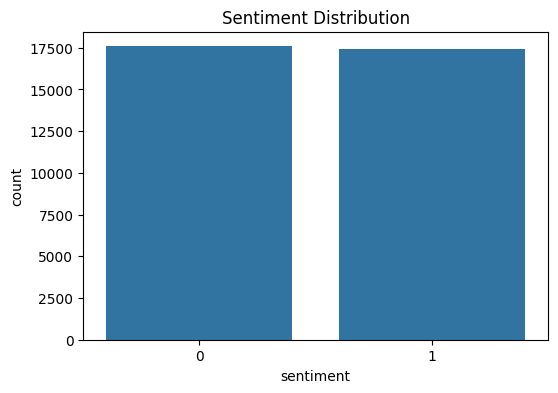

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x='sentiment', data=train_df)

plt.title("Sentiment Distribution")
plt.show()

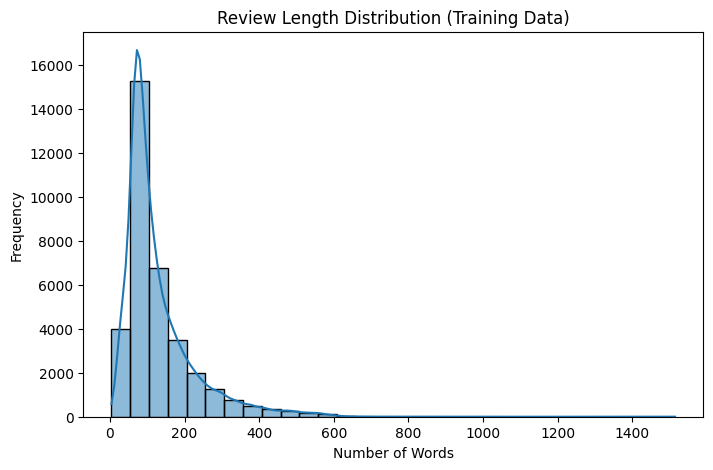

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

train_df['review_length'] = train_df['clean_review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(train_df['review_length'], bins=30, kde=True)
plt.title("Review Length Distribution (Training Data)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

**Simple RNN**

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dropout, Dense
from tensorflow.keras.optimizers import Adam

rnn_model = Sequential()

rnn_model.add(Input(shape=(max_length,)))

rnn_model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        mask_zero=True
    )
)

rnn_model.add(
    SimpleRNN(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)

rnn_model.add(Dropout(0.5))

rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,433,025 (24.54 MB)

 Trainable params: 6,433,025 (24.54 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [32]:
history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 197s 354ms/step - accuracy: 0.5068 - loss: 0.7301 - val_accuracy: 0.5098 - val_loss: 0.6944
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 188s 344ms/step - accuracy: 0.5157 - loss: 0.6980 - val_accuracy: 0.5398 - val_loss: 0.6900
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 193s 352ms/step - accuracy: 0.5314 - loss: 0.6901 - val_accuracy: 0.5282 - val_loss: 0.6874
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 187s 342ms/step - accuracy: 0.5706 - loss: 0.6726 - val_accuracy: 0.6204 - val_loss: 0.6488
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 192s 350ms/step - accuracy: 0.6733 - loss: 0.6069 - val_accuracy: 0.6998 - val_loss: 0.5718
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 210s 366ms/step - accuracy: 0.7540 - loss: 0.5157 - val_accuracy: 0.7196 - val_loss: 0.5671
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 211s 386ms/step - accuracy: 0.7989 - loss: 0.4456 - val_accuracy: 0.7794 - val_loss: 0.4820
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 195s 356ms/step - accuracy: 0.8364 -

In [34]:
rnn_loss, rnn_acc = rnn_model.evaluate(X_test_pad, y_test)
print("RNN Test Accuracy:", rnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8141 - loss: 0.4574
RNN Test Accuracy: 0.8141000270843506


In [35]:
rnn_pred = (rnn_model.predict(X_test_pad) > 0.4).astype(int).flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step


In [36]:
print(train_df['sentiment'].value_counts())

sentiment
0    17584
1    17416
Name: count, dtype: int64


In [37]:
print(classification_report(y_test, rnn_pred))

              precision    recall  f1-score   support

           0       0.85      0.75      0.79      4961
           1       0.78      0.87      0.82      5039

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



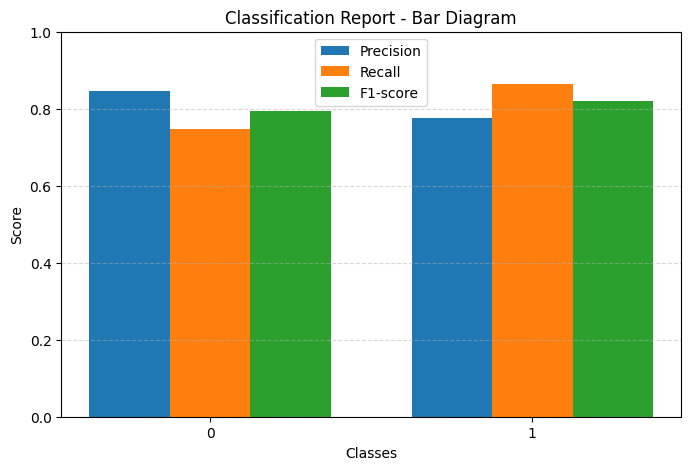

In [38]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(y_test, rnn_pred, output_dict=True)

classes = [label for label in report.keys() if label.isdigit()]

precision = [report[c]['precision'] for c in classes]
recall = [report[c]['recall'] for c in classes]
f1_score = [report[c]['f1-score'] for c in classes]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1_score, width, label='F1-score')

plt.xlabel("Classes")
plt.ylabel("Score")
plt.title("Classification Report - Bar Diagram")
plt.xticks(x, classes)
plt.ylim(0, 1)
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

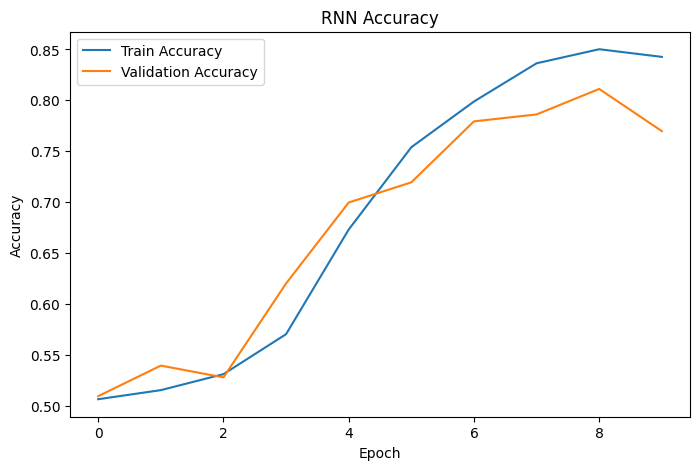

In [39]:
plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')

plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("RNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

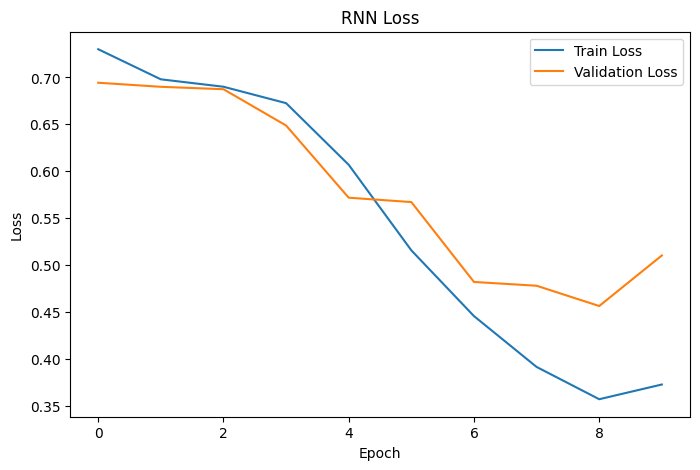

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['loss'], label='Train Loss')

plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("RNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

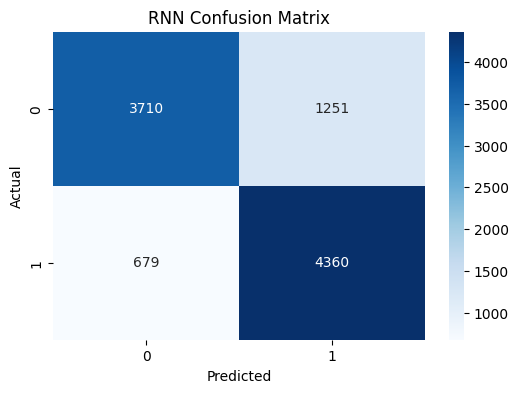

In [41]:
cm = confusion_matrix(y_test, rnn_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("RNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [42]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("\n Error Analysis Results (RNN):\n")

for i in range(5):

    text = X_test.iloc[i]

    seq = tokenizer.texts_to_sequences([text])

    pad = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

    pred = rnn_model.predict(pad)[0][0]

    label = 1 if pred >= 0.4 else 0

    print("Text:", text)
    print("Actual:", y_test.iloc[i])
    print("Predicted:", label)
    print("Confidence:", pred)
    print("-" * 50)


 Error Analysis Results (RNN):

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Text: really liked summerslam due look arena, curtains look overall interesting reason. anyways, could one best summerslam's ever wwf lex luger main event yokozuna, time ok huge fat man vs strong man but glad times changed. terrible main event like every match luger terrible. matches card razor ramon vs ted dibiase, steiner brothers vs heavenly bodies, shawn michaels vs curt hening, event shawn named big monster body guard diesel, irs vs -- kid, bret hart first takes doink takes jerry lawler stuff harts lawler always very interesting, ludvig borga destroyed marty jannetty, undertaker took giant gonzalez another terrible match, smoking gunns tatanka took bam bam bigelow headshrinkers, yokozuna defended world title lex luger match boring terrible ending. however deserves /
Actual: 1
Predicted: 0
Confidence: 0.2964282
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Text: not man

**LSTM Baseline**

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dropout, Dense, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_length,)))

lstm_model.add(Embedding(
    input_dim=max_words,
    output_dim=128,
    mask_zero=True
))

lstm_model.add(Bidirectional(LSTM(128, return_sequences=True)))
lstm_model.add(BatchNormalization())
lstm_model.add(Dropout(0.4))

lstm_model.add(Bidirectional(LSTM(64)))

lstm_model.add(Dropout(0.6))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0003),
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 300, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 300, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 300, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,828,673 (26.05 MB)

 Trainable params: 6,828,161 (26.05 MB)

 Non-trainable params: 512 (2.00 KB)

In [46]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 2080s 4s/step - accuracy: 0.8312 - loss: 0.3670 - val_accuracy: 0.8808 - val_loss: 0.2928
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1860s 3s/step - accuracy: 0.9443 - loss: 0.1539 - val_accuracy: 0.8806 - val_loss: 0.3398
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 2041s 4s/step - accuracy: 0.9781 - loss: 0.0669 - val_accuracy: 0.8704 - val_loss: 0.4579


In [47]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)

print("LSTM Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 168s 536ms/step - accuracy: 0.8865 - loss: 0.2839
LSTM Accuracy: 0.8865000009536743


In [48]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)

print("Test Loss:", lstm_loss)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 168s 536ms/step - accuracy: 0.8865 - loss: 0.2839
Test Loss: 0.2838538885116577
Test Accuracy: 0.8865000009536743


In [49]:
lstm_pred = lstm_model.predict(X_test_pad)
lstm_pred = (lstm_pred > 0.4).astype(int).flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 180s 567ms/step


In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lstm_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      4961
           1       0.89      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



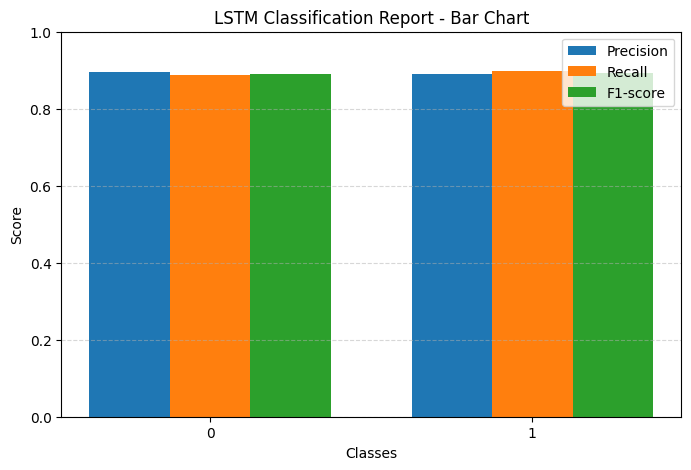

In [51]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(y_test, lstm_pred, output_dict=True)

classes = [label for label in report.keys() if label.isdigit()]

precision = [report[c]['precision'] for c in classes]
recall = [report[c]['recall'] for c in classes]
f1_score = [report[c]['f1-score'] for c in classes]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1_score, width, label='F1-score')

plt.xlabel("Classes")
plt.ylabel("Score")
plt.title("LSTM Classification Report - Bar Chart")
plt.xticks(x, classes)
plt.ylim(0, 1)
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

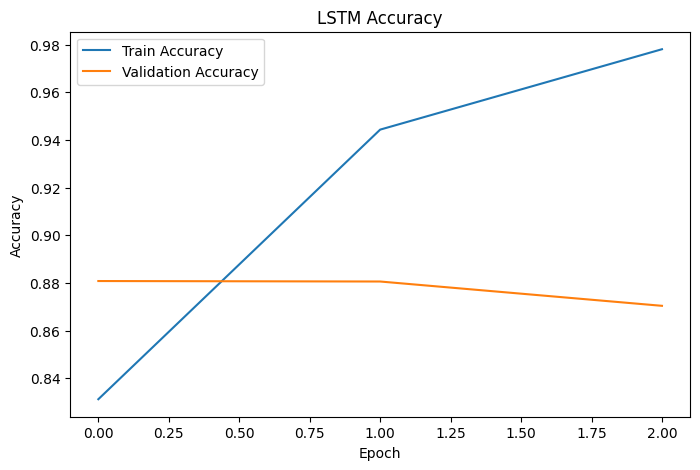

In [52]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

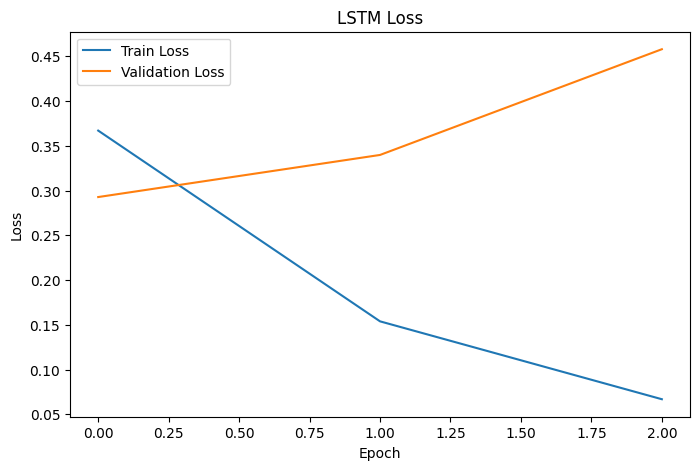

In [53]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

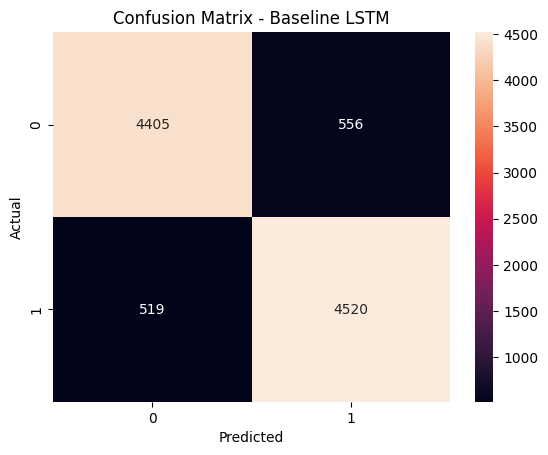

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, lstm_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Baseline LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [55]:
for i in range(5):

    text = X_test.iloc[i]

    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

    pred = lstm_model.predict(pad)[0][0]

    label = 1 if pred >= 0.4 else 0

    print("Text:", text)
    print("Actual:", y_test.iloc[i])
    print("Predicted:", label)
    print("Confidence:", pred)
    print("-" * 50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
Text: really liked summerslam due look arena, curtains look overall interesting reason. anyways, could one best summerslam's ever wwf lex luger main event yokozuna, time ok huge fat man vs strong man but glad times changed. terrible main event like every match luger terrible. matches card razor ramon vs ted dibiase, steiner brothers vs heavenly bodies, shawn michaels vs curt hening, event shawn named big monster body guard diesel, irs vs -- kid, bret hart first takes doink takes jerry lawler stuff harts lawler always very interesting, ludvig borga destroyed marty jannetty, undertaker took giant gonzalez another terrible match, smoking gunns tatanka took bam bam bigelow headshrinkers, yokozuna defended world title lex luger match boring terrible ending. however deserves /
Actual: 1
Predicted: 0
Confidence: 0.33243957
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
Text: not many television shows appeal quit

**LSTM with word2vec**

In [56]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.5 MB/s eta 0:00:00


In [57]:
import gensim.downloader as api

word2vec = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [58]:
import numpy as np

embedding_dim = 100

word_index = tokenizer.word_index

embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words:
        if word in word2vec:
            embedding_matrix[i] = word2vec[word]

In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

lstm_V_model = Sequential()

lstm_V_model.add(Input(shape=(max_length,)))

lstm_V_model.add(
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True
    )
)

lstm_V_model.add(LSTM(64, return_sequences=True))
lstm_V_model.add(Dropout(0.3))

lstm_V_model.add(LSTM(32))
lstm_V_model.add(Dropout(0.5))

lstm_V_model.add(Dense(1, activation='sigmoid'))

lstm_V_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 300, 100)       │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 300, 64)        │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 300, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,054,689 (19.28 MB)

 Trainable params: 5,054,689 (19.28 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
lstm_V_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [61]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [62]:
history_lstm_glove = lstm_V_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 511s 456ms/step - accuracy: 0.5100 - loss: 0.6916 - val_accuracy: 0.5090 - val_loss: 0.6879
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 521s 474ms/step - accuracy: 0.5393 - loss: 0.6749 - val_accuracy: 0.5122 - val_loss: 0.6811
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 535s 489ms/step - accuracy: 0.6797 - loss: 0.5531 - val_accuracy: 0.8570 - val_loss: 0.3723
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 497s 454ms/step - accuracy: 0.8835 - loss: 0.3118 - val_accuracy: 0.8738 - val_loss: 0.3169
Epoch 5/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 474s 433ms/step - accuracy: 0.9267 - loss: 0.2178 - val_accuracy: 0.8824 - val_loss: 0.3143
Epoch 6/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 478s 437ms/step - accuracy: 0.9553 - loss: 0.1532 - val_accuracy: 0.8878 - val_loss: 0.3428
Epoch 7/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 467s 426ms/step - accuracy: 0.9696 - loss: 0.1155 - val_accuracy: 0.8876 - val_loss: 0.3835


In [63]:
lstm_w2v_loss, lstm_w2v_acc = lstm_V_model.evaluate(X_test_pad, y_test)

print("Word2Vec LSTM Accuracy:", lstm_w2v_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.8772 - loss: 0.3167
Word2Vec LSTM Accuracy: 0.8772000074386597


In [64]:
lstm_V_pred = lstm_V_model.predict(X_test_pad)
lstm_V_pred = (lstm_V_pred >= 0.4).astype(int).flatten()

print(classification_report(y_test, lstm_V_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 84ms/step
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      4961
           1       0.86      0.91      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



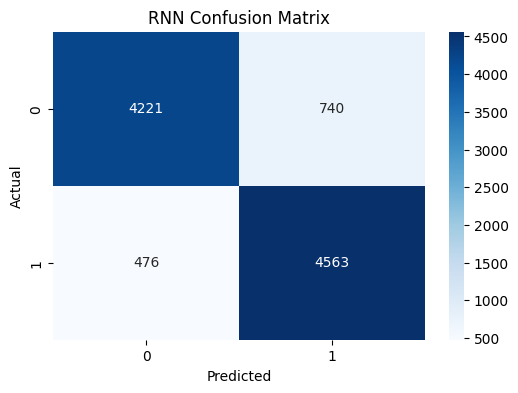

In [65]:
cm = confusion_matrix(y_test, lstm_V_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("RNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [66]:
for i in range(5):

    text = X_test.iloc[i]

    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

    pred = lstm_V_model.predict(pad)[0][0]

    label = 1 if pred >= 0.4 else 0

    print("Text:", text)
    print("Actual:", y_test.iloc[i])
    print("Predicted:", label)
    print("Confidence:", pred)
    print("-" * 50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Text: really liked summerslam due look arena, curtains look overall interesting reason. anyways, could one best summerslam's ever wwf lex luger main event yokozuna, time ok huge fat man vs strong man but glad times changed. terrible main event like every match luger terrible. matches card razor ramon vs ted dibiase, steiner brothers vs heavenly bodies, shawn michaels vs curt hening, event shawn named big monster body guard diesel, irs vs -- kid, bret hart first takes doink takes jerry lawler stuff harts lawler always very interesting, ludvig borga destroyed marty jannetty, undertaker took giant gonzalez another terrible match, smoking gunns tatanka took bam bam bigelow headshrinkers, yokozuna defended world title lex luger match boring terrible ending. however deserves /
Actual: 1
Predicted: 0
Confidence: 0.10456063
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Text: not many television shows appeal quite 

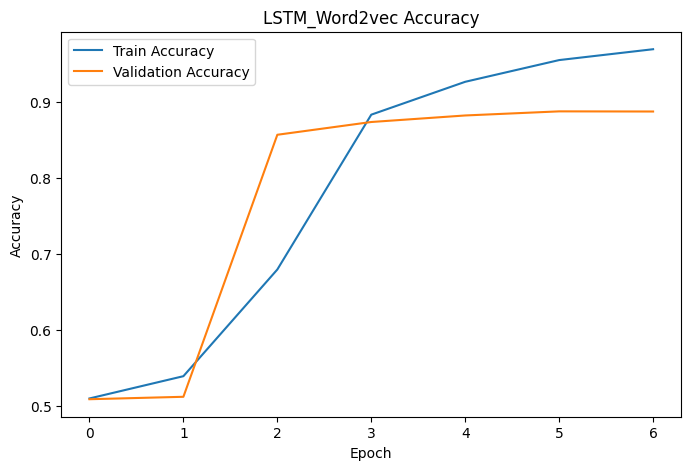

In [67]:
plt.figure(figsize=(8,5))

plt.plot(history_lstm_glove.history['accuracy'], label='Train Accuracy')

plt.plot(history_lstm_glove.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM_Word2vec Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

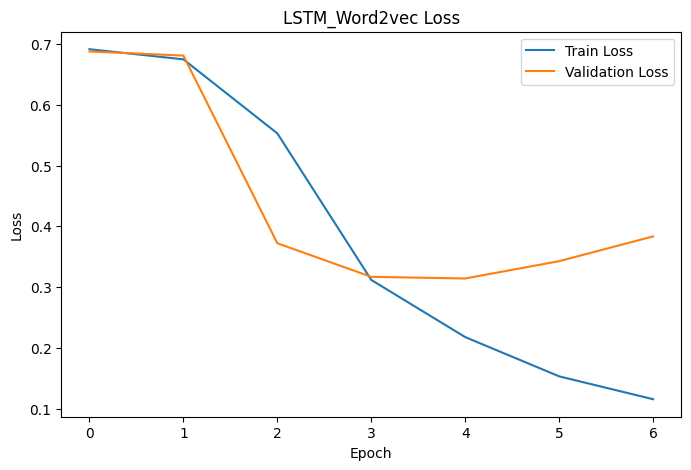

In [68]:
plt.figure(figsize=(8,5))

plt.plot(history_lstm_glove.history['loss'], label='Train Loss')

plt.plot(history_lstm_glove.history['val_loss'], label='Validation Loss')

plt.title("LSTM_Word2vec Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

**Model Comparision**

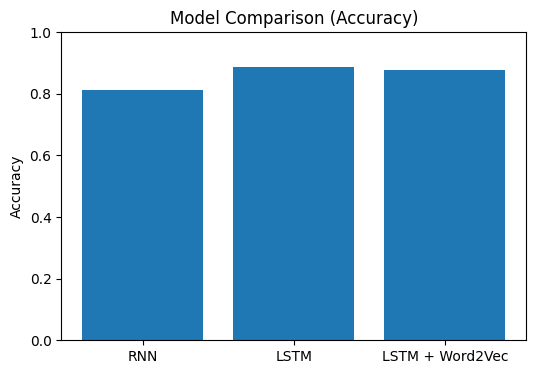

In [69]:
import matplotlib.pyplot as plt

models = ['RNN', 'LSTM', 'LSTM + Word2Vec']

accuracies = [rnn_acc, lstm_acc, lstm_w2v_acc]

plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

In [70]:
rnn_pred = (rnn_model.predict(X_test_pad) > 0.4).astype(int).flatten()
lstm_pred = (lstm_model.predict(X_test_pad) > 0.4).astype(int).flatten()
lstm_v_pred = (lstm_V_model.predict(X_test_pad) > 0.4).astype(int).flatten()


rnn_errors = sum(rnn_pred != y_test)
lstm_errors = sum(lstm_pred != y_test)
lstm_v_errors = sum(lstm_v_pred != y_test)

print("\n================ MODEL COMPARISON ================\n")

print("1. SIMPLE RNN MODEL")
print("- Struggles with long-term dependencies")
print("- Poor handling of negation and context")
print("- Highest number of misclassifications:", rnn_errors)
print("- Limited understanding of semantic meaning\n")

print("2. BASIC LSTM MODEL")
print("- Better than RNN in capturing sequence information")
print("- Handles context and negation better")
print("- Still makes mistakes on semantic similarity cases")
print("- Misclassifications:", lstm_errors)
print("- Moderate generalization ability\n")

print("3. WORD2VEC + LSTM MODEL")
print("- Uses pretrained embeddings for semantic understanding")
print("- Captures word meaning relationships effectively")
print("- Best performance on unseen data")
print("- Lowest misclassifications:", lstm_v_errors)
print("- Strong generalization and contextual understanding\n")


errors = {
    "RNN": rnn_errors,
    "LSTM": lstm_errors,
    "Word2Vec_LSTM": lstm_v_errors
}

best_model = min(errors, key=errors.get)

print("\n================ FINAL RESULT ================\n")
print("Best Model Selected:", best_model)
print("Reason: It has the lowest misclassification and best contextual understanding.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 201s 642ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 94ms/step

================ MODEL COMPARISON ================

1. SIMPLE RNN MODEL
- Struggles with long-term dependencies
- Poor handling of negation and context
- Highest number of misclassifications: 1930
- Limited understanding of semantic meaning

2. BASIC LSTM MODEL
- Better than RNN in capturing sequence information
- Handles context and negation better
- Still makes mistakes on semantic similarity cases
- Misclassifications: 1075
- Moderate generalization ability

3. WORD2VEC + LSTM MODEL
- Uses pretrained embeddings for semantic understanding
- Captures word meaning relationships effectively
- Best performance on unseen data
- Lowest misclassifications: 1216
- Strong generalization and contextual understanding


================ FINAL RESULT ================

Best Model Selected: LSTM
Reason: It has the lowest misclassification and best contextual understand

**GUI**


In [71]:
!pip uninstall -y gradio gradio_client huggingface_hub

Found existing installation: gradio 5.50.0
Uninstalling gradio-5.50.0:
  Successfully uninstalled gradio-5.50.0
Found existing installation: gradio_client 1.14.0
Uninstalling gradio_client-1.14.0:
  Successfully uninstalled gradio_client-1.14.0
Found existing installation: huggingface_hub 1.11.0
Uninstalling huggingface_hub-1.11.0:
  Successfully uninstalled huggingface_hub-1.11.0


In [72]:
!pip install gradio==4.44.1 huggingface_hub==0.25.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.6/436.6 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: websockets
    Found existing installation: websockets 15.0.1
    Uninstalling websockets-15.0.1:
      Successfully uninstalled websockets-15.0.1
  Attempting uninstall: tomlkit
    Found existing installation: tomlkit 0.13.3
    Uninstalling tomlkit-0.13.3:
      Successfully uninstalled tomlkit-0.13.3
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.3
    Uninstalling MarkupSafe-3.0.3

In [1]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(text):

    text = clean_text(text)

    seq = tokenizer.texts_to_sequences([text])

    pad = pad_sequences(seq, maxlen=max_length, padding='post')

    pred = lstm_model.predict(pad)[0][0]

    if pred >= 0.4:
        label = "Positive 😊"
    else:
        label = "Negative 😞"

    return f"{label}\nConfidence Score: {pred:.4f}"

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Enter a movie review or tweet..."
    ),
    outputs=gr.Textbox(),
    title="🎬 Sentiment Analysis System",
    description="LSTM-based real-time sentiment prediction"
)

demo.launch()

Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://7e7b265371c8487bba.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
